# OptiCore - Positioning & Flow

Open interest and volume aren't priced the way greeks are, but they say where the
crowd already sits and where today's money is moving. This notebook walks the
positioning and flow analytics on the sample chain and, more to the point, how to
read what they print:

1. OI walls - support and resistance from open interest
2. Max pain - the settlement magnet near expiry
3. Put/call ratio - the standing book vs the day's flow
4. Turnover and dollar volume - where contracts and premium actually move
5. By-strike vs per-expiry - when the summary hides the skew

All of it is pure open-interest and volume arithmetic - no IV solve - so it runs on
any chain that carries `open_interest`, offline on the bundled sample.

## 0. Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import opticore as oc
import pandas as pd

pd.set_option("display.precision", 3)

chain = oc.fetch_chain("SPY", provider="sample")
spot = chain["underlying_price"].iloc[0]
expiries = sorted(chain["expiry"].unique())
near = expiries[0]

print(f"spot ${spot:.2f}, {len(expiries)} expiries, nearest {str(near)[:10]}")

spot $510.00, 6 expiries, nearest 2026-07-04


None of the calls below take a rate or solve for IV - they read `open_interest` and
`volume` straight off the chain, so there's no `enrich` step here.

## 1. OI walls

The walls are the strikes carrying the most open interest on each side. They tend to
act as magnets into expiry: dealers who are short those options hedge against price
moving through them, and that hedging flow leans against the move. The call wall reads
as overhead resistance, the put wall as support - on a real chain, where the big OI
usually piles up out of the money on both sides.

In [2]:
walls = oc.oi_walls(chain)
walls[["expiry", "call_wall", "call_wall_oi", "put_wall", "put_wall_oi"]]

,expiry,call_wall,call_wall_oi,put_wall,put_wall_oi
0,2026-07-04 10:11:58.181166+00:00,503.5,9820.0,518.5,11868.0
1,2026-07-11 10:11:58.181166+00:00,518.5,8973.0,528.5,9667.0
2,2026-08-01 10:11:58.181166+00:00,518.5,8539.0,523.5,10340.0
3,2026-09-05 10:11:58.181166+00:00,493.5,9844.0,508.5,10657.0
4,2026-12-26 10:11:58.181166+00:00,518.5,10224.0,523.5,8339.0
5,2027-03-27 10:11:58.181166+00:00,538.5,9082.0,513.5,10044.0


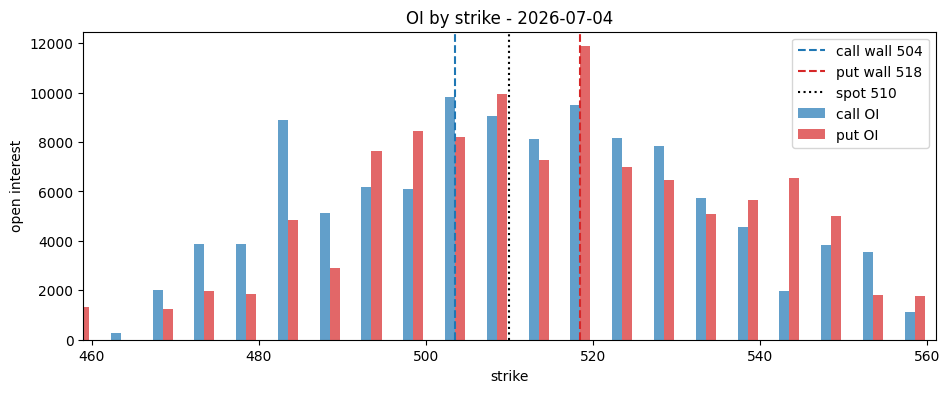

In [3]:
oi = (
    chain[chain["expiry"] == near]
    .pivot_table(index="strike", columns="kind", values="open_interest", aggfunc="sum")
    .fillna(0.0)
)
w = walls[walls["expiry"] == near].iloc[0]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(oi.index - 0.6, oi.get("call", 0), width=1.2, color="tab:blue", alpha=0.7, label="call OI")
ax.bar(oi.index + 0.6, oi.get("put", 0), width=1.2, color="tab:red", alpha=0.7, label="put OI")
ax.axvline(w["call_wall"], color="tab:blue", ls="--", label=f"call wall {w['call_wall']:.0f}")
ax.axvline(w["put_wall"], color="tab:red", ls="--", label=f"put wall {w['put_wall']:.0f}")
ax.axvline(spot, color="black", ls=":", label=f"spot {spot:.0f}")
ax.set(xlabel="strike", ylabel="open interest", title=f"OI by strike - {str(near)[:10]}")
ax.set_xlim(spot * 0.9, spot * 1.1)
ax.legend()
plt.show()

The sample is synthetic, so the OI doesn't pile up neatly out of the money the way a
live SPY chain would - here the heaviest strikes sit close to spot and the walls don't
straddle it cleanly. The reading is the same regardless: find where the bars spike and
watch how price behaves into it. `call_wall_oi` and `put_wall_oi` tell you how much
conviction is actually parked there - a wall with thin OI is not much of a wall.

## 2. Max pain

Max pain is the settlement price where the total intrinsic payout owed to holders is
smallest - where writers, as a group, give back the least. It's pure OI arithmetic:
for every listed strike, sum what each call and put would pay at that price and pick
the minimum. Near expiry it's quoted as a pin, on the same dealer-hedging logic as the
walls. Far from expiry it means little - there's too much time for the book to move.

In [4]:
mp = oc.max_pain(chain)
mp["days"] = (mp["expiry"] - chain["expiry"].min()).dt.days
mp[["expiry", "days", "max_pain_strike", "total_oi", "pain_at_max_pain"]]

,expiry,days,max_pain_strike,total_oi,pain_at_max_pain
0,2026-07-04 10:11:58.181166+00:00,0,513.5,231303.0,2.583e+06
1,2026-07-11 10:11:58.181166+00:00,7,513.5,198808.0,2.167e+06
2,2026-08-01 10:11:58.181166+00:00,28,513.5,214652.0,2.558e+06
3,2026-09-05 10:11:58.181166+00:00,63,508.5,219403.0,2.670e+06
4,2026-12-26 10:11:58.181166+00:00,175,513.5,227720.0,2.600e+06
5,2027-03-27 10:11:58.181166+00:00,266,508.5,213572.0,2.033e+06


Read the nearest row first: it's the only one close enough for the pin to bite. The
front-month `max_pain_strike` is the level that argument points at into expiry, and
`total_oi` is the weight behind it - a max-pain strike backed by little open interest
is a weak signal. The back-month rows are there for completeness; don't trade a pin
that's months out.

## 3. Put/call ratio

The put/call ratio is a crude sentiment gauge - more puts than calls (above 1) reads
defensive, below 1 bullish. The point of reporting both cuts is that they often
disagree: `oi_pcr` is the standing book built up over weeks, `volume_pcr` is just
today's flow. When the day's flow runs opposite the book, positioning is shifting.

In [5]:
pcr = oc.pcr(chain)
pcr["oi_vs_flow"] = np.where(
    np.sign(pcr["oi_pcr"] - 1) == np.sign(pcr["volume_pcr"] - 1), "agree", "diverge"
)
pcr[["expiry", "oi_pcr", "volume_pcr", "oi_vs_flow"]]

,expiry,oi_pcr,volume_pcr,oi_vs_flow
0,2026-07-04 10:11:58.181166+00:00,0.940,1.016,diverge
1,2026-07-11 10:11:58.181166+00:00,1.037,0.909,diverge
2,2026-08-01 10:11:58.181166+00:00,1.115,0.920,diverge
3,2026-09-05 10:11:58.181166+00:00,0.990,0.989,agree
4,2026-12-26 10:11:58.181166+00:00,1.165,1.249,agree
5,2027-03-27 10:11:58.181166+00:00,0.908,0.980,agree


Rows tagged `diverge` are the interesting ones: the book leans one way and the day is
buying the other. A `volume_pcr` well above the `oi_pcr` is fresh put buying that the
open interest hasn't caught up to yet. Either ratio is NaN when the call side is zero -
the row still prints so the put total stays visible.

## 4. Turnover and dollar volume

Two flow cuts. Turnover is the day's volume over standing open interest, per side: near
or above 1 means roughly as much traded today as was already open, which flags fresh
positioning rather than carry. Dollar volume weights each strike by its price, so a
handful of deep ITM contracts can outweigh a swarm of cheap wings - it shows where the
premium sits, not just the contract count.

In [6]:
turn = oc.turnover(chain)
turn[["expiry", "call_turnover", "put_turnover"]]

,expiry,call_turnover,put_turnover
0,2026-07-04 10:11:58.181166+00:00,0.242,0.261
1,2026-07-11 10:11:58.181166+00:00,0.276,0.242
2,2026-08-01 10:11:58.181166+00:00,0.265,0.219
3,2026-09-05 10:11:58.181166+00:00,0.236,0.235
4,2026-12-26 10:11:58.181166+00:00,0.238,0.255
5,2027-03-27 10:11:58.181166+00:00,0.231,0.250


In [7]:
dv = oc.dollar_volume(chain)
dv[["expiry", "call_dollar_volume", "put_dollar_volume", "dollar_volume_pcr", "dollar_oi_pcr"]]

,expiry,call_dollar_volume,put_dollar_volume,dollar_volume_pcr,dollar_oi_pcr
0,2026-07-04 10:11:58.181166+00:00,3.963e+07,3.649e+07,0.921,1.086
1,2026-07-11 10:11:58.181166+00:00,2.727e+07,2.905e+07,1.065,1.064
2,2026-08-01 10:11:58.181166+00:00,4.922e+07,4.342e+07,0.882,1.275
3,2026-09-05 10:11:58.181166+00:00,5.024e+07,4.759e+07,0.947,0.940
4,2026-12-26 10:11:58.181166+00:00,6.847e+07,6.863e+07,1.002,0.909
5,2027-03-27 10:11:58.181166+00:00,1.011e+08,6.394e+07,0.633,0.610


Compare `dollar_volume_pcr` against the plain `volume_pcr` from section 3. When the
dollar ratio leans more bearish than the count ratio, the puts trading are the
expensive ones - more money is going into downside than the contract tally suggests.
`dollar_oi_pcr` does the same for the standing book.

## 5. By-strike vs per-expiry

The per-expiry summaries above collapse the whole chain into one number per expiry. That
hides the shape. The `*_by_strike` variants keep the strike axis, aggregated across
expiries, so you can see a balanced headline ratio that's actually lopsided strike by
strike.

In [8]:
by_strike = oc.pcr_by_strike(chain)
window = by_strike[(by_strike["strike"] >= spot * 0.95) & (by_strike["strike"] <= spot * 1.05)]
window[["strike", "call_oi", "put_oi", "oi_pcr", "volume_pcr"]]

,strike,call_oi,put_oi,oi_pcr,volume_pcr
11,488.5,30487.0,30619.0,1.004,0.998
12,493.5,44301.0,38546.0,0.870,0.824
13,498.5,39355.0,42811.0,1.088,1.018
14,503.5,48582.0,41563.0,0.856,0.974
15,508.5,49332.0,51183.0,1.038,1.055
16,513.5,47773.0,47554.0,0.995,1.183
17,518.5,47924.0,47833.0,0.998,0.913
18,523.5,45975.0,48958.0,1.065,1.028
19,528.5,41668.0,40736.0,0.978,1.148
20,533.5,31127.0,29613.0,0.951,1.030


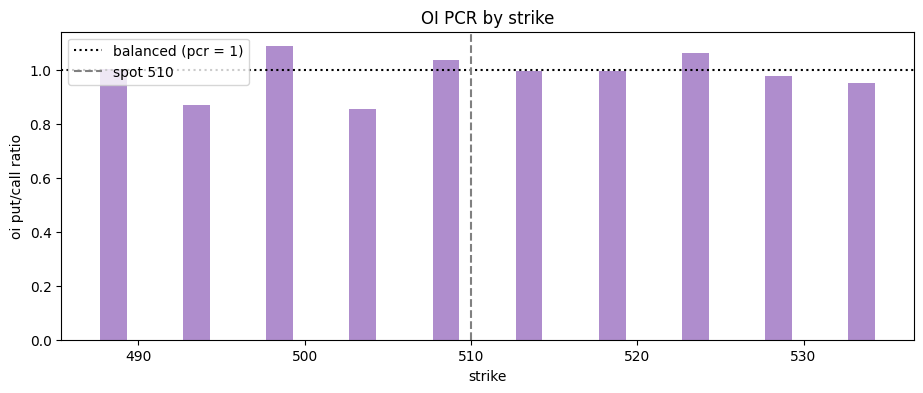

In [9]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(window["strike"], window["oi_pcr"], width=1.6, color="tab:purple", alpha=0.75)
ax.axhline(1.0, color="black", ls=":", label="balanced (pcr = 1)")
ax.axvline(spot, color="gray", ls="--", label=f"spot {spot:.0f}")
ax.set(xlabel="strike", ylabel="oi put/call ratio", title="OI PCR by strike")
ax.legend()
plt.show()

Bars above the dotted line are put-heavy strikes, below it call-heavy. A chain whose
headline `oi_pcr` sits near 1 can still be firmly put-heavy below spot and call-heavy
above - the by-strike view is what tells you that, and it's where the walls and the
max-pain magnet come from in the first place. Reach for the per-expiry summary for a
quick sentiment read; reach for by-strike when you need to know *where* the positioning
is.